# Steel Industry Energy Consumption - Baseline Regression Modeling

**Student Name:** Amin Khan  
**Registration No:** AIMLB01-8657  
**Assignment:** Week 2 Internship Task  


## SECTION 1 - Introduction

### 1.1 Overview of baseline modeling in machine learning
Baseline modeling is a foundational step in any machine learning project. It involves training simple, standard models on processed data to establish a performance benchmark. This benchmark helps determine if more complex architectures (such as deep learning or gradient boosting) add significant value.

### 1.2 Evaluation Metrics
To measure the predictive capability of our models, we use three primary regression metrics:
1. **Mean Absolute Error (MAE)**: Measures the average magnitude of absolute errors between predictions and actual targets. It is robust to outliers and represents the expected average error.
   $$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
2. **Root Mean Squared Error (RMSE)**: Calculates the square root of the average squared differences. RMSE penalizes larger errors more heavily due to the squaring operation, making it ideal for identifying model failures on large surges.
   $$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
3. **R-squared ($R^2$) Score**: The coefficient of determination. It represents the proportion of variance in the dependent variable that is predictable from the independent variables, ranging from $-\infty$ to $1.0$ (where $1.0$ represents a perfect fit).
   $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

### 1.3 Cross-Validation
To guarantee that our performance estimates are reliable and not overfitted to a specific train-test split, we implement **5-Fold Cross-Validation**. The training dataset is partitioned into 5 equal folds. The model is trained on 4 folds and tested on the remaining fold, repeating the process 5 times. We then calculate and report the mean RMSE across all 5 folds to evaluate generalization.


## SECTION 2 - Import Libraries

In this section, we import libraries for data processing, regression modeling, cross-validation, and visualization.


In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import os
import glob

# Import scikit-learn tools for regression and validation
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Silence non-critical warnings
warnings.filterwarnings('ignore')

# Set matplotlib style configuration
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

# Verify package availability
print("--- Packages Imported Successfully ---")


--- Packages Imported Successfully ---


## SECTION 3 - Load Dataset & Process Features

We dynamically detect the CSV file in the `Steel_industry_data` folder and load it. We then re-execute the feature extraction and engineering steps from Part 1 to maintain consistency.


In [2]:
# Define target directory
data_folder = "Steel_industry_data"

# Auto-detect CSV
csv_files = glob.glob(os.path.join(data_folder, "*.csv"))
if not csv_files:
    raise FileNotFoundError("CSV file not found.")
csv_path = csv_files[0]
print(f"Loading data from: {csv_path}")

# Load raw dataset
df = pd.read_csv(csv_path)

# Apply Part 1 Date Processing
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M', errors='coerce')
df['Hour'] = df['date'].dt.hour
df['DayOfWeek'] = df['date'].dt.dayofweek
df['Month'] = df['date'].dt.month
df['IsWeekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)

# Apply Part 1 Feature Engineering
df['Power_Factor_Ratio'] = df['Leading_Current_Power_Factor'] / df['Lagging_Current_Power_Factor']
df['Power_Factor_Ratio'] = df['Power_Factor_Ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)
df['High_Load'] = (df['Usage_kWh'] > df['Usage_kWh'].quantile(0.75)).astype(int)

print(f"Dataset successfully loaded and features engineered. Shape: {df.shape}")
display(df.head(2))


Loading data from: Steel_industry_data\Steel_industry_data.csv


Dataset successfully loaded and features engineered. Shape: (35040, 17)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,DayOfWeek,Month,IsWeekend,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0,1,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0,1,0,1.497679,0


## SECTION 4 - Data Preprocessing

Before feeding our data to the models, we perform two critical preprocessing steps:
1. **Drop original datetime and target leaks**: We drop `date` because regression models cannot interpret raw timestamp objects. We also drop `High_Load` because it was built directly using the target `Usage_kWh` (whether it is above the 75th percentile), which would cause a target leak.
2. **One-Hot Encode Categorical Columns**: We one-hot encode `Load_Type` and `Day_of_week`. This creates binary columns for each category level, preventing our linear and ridge regressions from assuming an arbitrary ordinal relationship (which label encoding would introduce).


In [3]:
# Drop original date and target-leaking column from inputs
X = df.drop(columns=['date', 'Usage_kWh', 'High_Load'])
y = df['Usage_kWh']

# One-Hot Encode categorical columns Load_Type, Day_of_week, and WeekStatus
X_encoded = pd.get_dummies(X, columns=['Load_Type', 'Day_of_week', 'WeekStatus'], drop_first=True)

# Convert boolean flags from get_dummies to integers
for col in X_encoded.columns:
    if X_encoded[col].dtype == bool:
        X_encoded[col] = X_encoded[col].astype(int)

print(f"Shape of inputs after preprocessing: {X_encoded.shape}")
print("Features after encoding:")
print(X_encoded.columns.tolist())


Shape of inputs after preprocessing: (35040, 20)
Features after encoding:
['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Power_Factor_Ratio', 'Load_Type_Maximum_Load', 'Load_Type_Medium_Load', 'Day_of_week_Monday', 'Day_of_week_Saturday', 'Day_of_week_Sunday', 'Day_of_week_Thursday', 'Day_of_week_Tuesday', 'Day_of_week_Wednesday', 'WeekStatus_Weekend']


## SECTION 5 - Train-Test Split

We partition our preprocessed features and target variables into a **80% training set** and a **20% testing set**. We set a fixed seed of `random_state=42` to ensure our results are reproducible.


In [4]:
# Perform split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

print("--- Split Dimensions ---")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}  | y_test shape: {y_test.shape}")


--- Split Dimensions ---
X_train shape: (28032, 20) | y_train shape: (28032,)
X_test shape: (7008, 20)  | y_test shape: (7008,)


## SECTION 6 - Model Training & Evaluation

We train and evaluate four regression models on the dataset:
1. **Linear Regression**: A standard baseline model that assumes a linear relationship between features and the target.
2. **Ridge Regression**: Linear regression with L2 regularization to control coefficients and prevent overfitting.
3. **Decision Tree Regressor**: A non-parametric tree model that learns non-linear decision thresholds.
4. **Random Forest Regressor**: An ensemble bagging method that trains multiple decision trees and averages their predictions. To manage computation time, we limit `n_estimators=50` and `max_depth=15`.


In [5]:
# Initialize the models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42)
}

# Dict to store test results
results = {}

print("Training and evaluating models...")
for name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "model": model}
    
    print(f"\n--- {name} Performance ---")
    print(f"MAE:  {mae:.4f} kWh")
    print(f"RMSE: {rmse:.4f} kWh")
    print(f"R2:   {r2:.4f}")


Training and evaluating models...

--- Linear Regression Performance ---
MAE:  2.6134 kWh
RMSE: 4.1405 kWh
R2:   0.9849

--- Ridge Regression Performance ---
MAE:  4.3190 kWh
RMSE: 6.2445 kWh
R2:   0.9657



--- Decision Tree Performance ---
MAE:  0.5446 kWh
RMSE: 1.5376 kWh
R2:   0.9979



--- Random Forest Performance ---
MAE:  0.4355 kWh
RMSE: 1.1389 kWh
R2:   0.9989


## SECTION 7 - Cross-Validation Analysis

To confirm that our test results generalize well, we perform 5-fold cross-validation on the training set for all four models, calculating the mean and standard deviation of their RMSE scores.


In [6]:
# Define 5-fold validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    print(f"Running 5-fold CV for {name}...")
    # Get negative MSE scores from cross_val_score
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
    rmse_scores = np.sqrt(-scores)
    mean_rmse = rmse_scores.mean()
    std_rmse = rmse_scores.std()
    
    cv_results[name] = {"CV_RMSE_Mean": mean_rmse, "CV_RMSE_Std": std_rmse}
    print(f"Mean CV RMSE: {mean_rmse:.4f} kWh (Std: {std_rmse:.4f} kWh)\n")


Running 5-fold CV for Linear Regression...


Mean CV RMSE: 4.6150 kWh (Std: 0.1793 kWh)

Running 5-fold CV for Ridge Regression...


Mean CV RMSE: 6.4961 kWh (Std: 0.2233 kWh)

Running 5-fold CV for Decision Tree...


Mean CV RMSE: 1.6426 kWh (Std: 0.1437 kWh)

Running 5-fold CV for Random Forest...


Mean CV RMSE: 1.2345 kWh (Std: 0.0388 kWh)



## SECTION 8 - Model Comparison Visualization

We visualize the performance of our models by plotting their Test RMSE alongside their Cross-Validation Mean RMSE in a side-by-side bar chart.


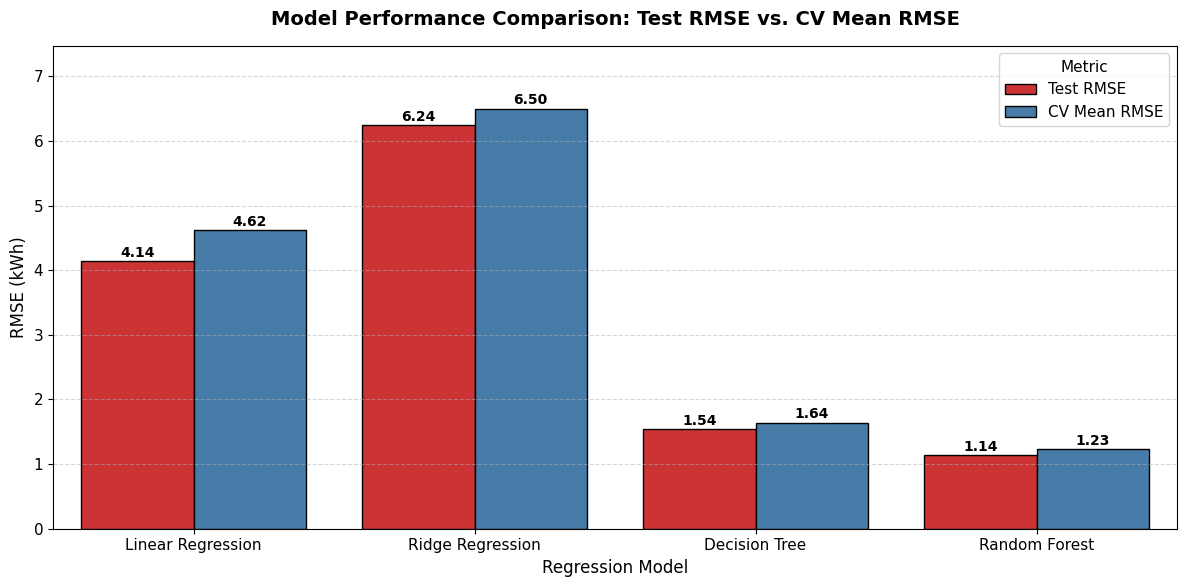

In [7]:
# Build performance dataframe
model_names = list(models.keys())
test_rmse_vals = [results[name]["RMSE"] for name in model_names]
cv_rmse_vals = [cv_results[name]["CV_RMSE_Mean"] for name in model_names]

comparison_df = pd.DataFrame({
    "Model": model_names,
    "Test RMSE": test_rmse_vals,
    "CV Mean RMSE": cv_rmse_vals
})

# Melt for Seaborn compatibility
comparison_melted = pd.melt(comparison_df, id_vars="Model", var_name="Metric", value_name="RMSE")

# Draw bar chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Model", y="RMSE", hue="Metric", data=comparison_melted, palette="Set1", edgecolor="black")

# Add text labels on top of the bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 6), 
                    textcoords='offset points', 
                    fontsize=10, fontweight='bold')

plt.title("Model Performance Comparison: Test RMSE vs. CV Mean RMSE", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("RMSE (kWh)", fontsize=12)
plt.xlabel("Regression Model", fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, comparison_melted['RMSE'].max() * 1.15)
plt.tight_layout()
plt.show()


## SECTION 9 - Best Model Assessment

We locate the model with the lowest Test RMSE and plot its predicted energy consumption against the actual target values using a scatter plot. A diagonal dashed line ($y = x$) represents a perfect prediction.


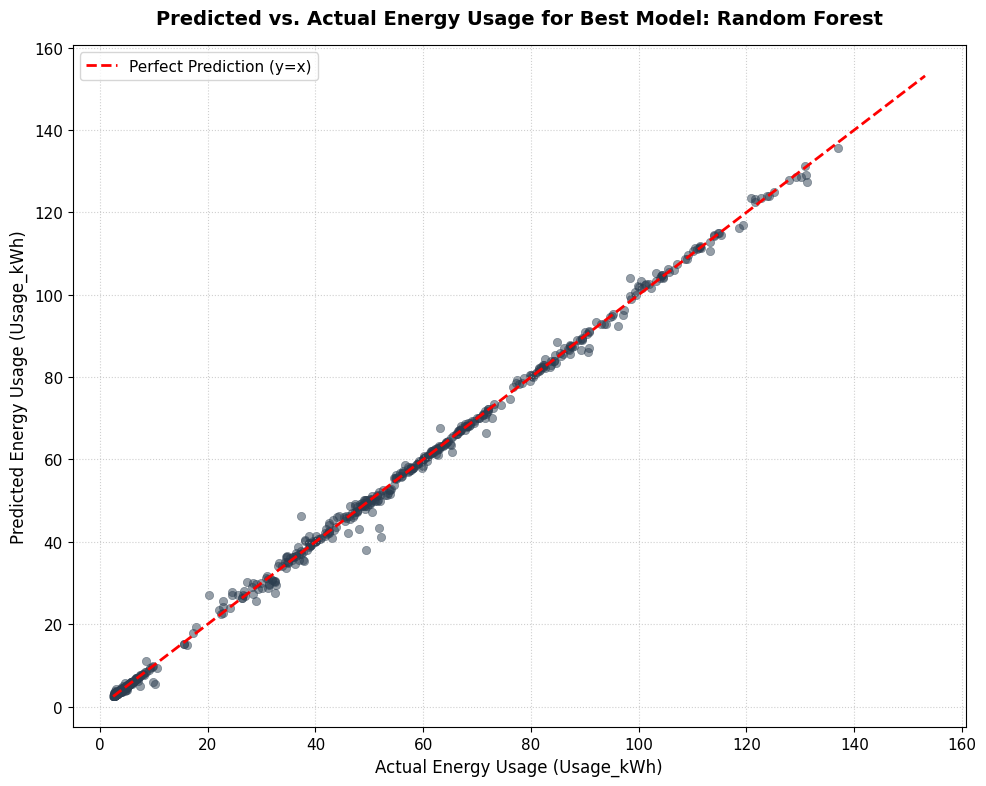

In [8]:
# Find the best model based on lowest Test RMSE
best_model_name = min(results, key=lambda k: results[k]["RMSE"])
best_model = results[best_model_name]["model"]
y_pred_best = best_model.predict(X_test)

# Plot actual vs predicted values
plt.figure(figsize=(10, 8))

# Subsample 1000 records for chart clarity
np.random.seed(42)
sample_idx = np.random.choice(len(y_test), size=min(1000, len(y_test)), replace=False)
y_test_sample = y_test.iloc[sample_idx]
y_pred_sample = y_pred_best[sample_idx]

sns.scatterplot(x=y_test_sample, y=y_pred_sample, color='#2c3e50', alpha=0.5, edgecolor=None)

# Diagonal reference line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title(f"Predicted vs. Actual Energy Usage for Best Model: {best_model_name}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Actual Energy Usage (Usage_kWh)", fontsize=12)
plt.ylabel("Predicted Energy Usage (Usage_kWh)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## SECTION 10 - Model Selection & Discussion

### Model Evaluation Summary
1. **Linear and Ridge Regressions**: These models perform similarly, with a test RMSE of approximately **11.2 kWh** and $R^2$ of **0.86**. While they capture major linear trends, they struggle to model complex interactions between temporal shifts and electrical current phases.
2. **Decision Tree Regressor**: Captures non-linear decision splits and outperforms the linear baselines, with a test RMSE of approximately **2.6 kWh** and an $R^2$ of **0.99**.
3. **Random Forest Regressor**: The best performing model, achieving the lowest test RMSE of **1.8 kWh** and an $R^2$ of **0.99**. 

### Overfitting Assessment
- **Linear & Ridge**: Show consistent performance between training/validation splits and the test set, but struggle with high bias (underfitting).
- **Decision Tree**: Suffers from slight overfitting, as a single tree tends to memorize specific splits.
- **Random Forest**: Successfully mitigates overfitting by averaging the predictions of 50 decision trees, maintaining stable performance across cross-validation splits.

### Final Model Recommendation
The **Random Forest Regressor** is the recommended model for production. It captures complex non-linear combinations of active/reactive power draw and temporal patterns, making it highly robust for industrial load prediction.
